# Lecture 28 — Multi-Task RL, Contextual Policies, and Meta-RL

This notebook implements core concepts from Lecture 28:

- Contextual / Goal-conditioned policies
- Memory-based Meta-RL (RL^2 / recurrent policies)
- Optimization-based Meta-RL (MAML-style inner-loop adaptation)

It includes runnable PyTorch code, compact training/evaluation skeletons, small unit tests and plotting helpers. The notebook is intended for learning and small-scale experiments (not full production training loops).


## 1) Setup: imports, device and deterministic seeds

This cell installs (if needed) and imports core libraries, sets device and provides a helper to set seeds for reproducibility.


In [1]:
# Standard imports
import os
import math
import random
import copy

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

# Utilities
from typing import Dict, Tuple, List, Any

# Device & seed helpers
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def set_seed(seed: int = 0):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

# Quick environment check
print(f"Using device: {DEVICE}")
print(f"PyTorch version: {torch.__version__}")

# Make experiments reproducible by default in this notebook
set_seed(0)


Using device: cpu
PyTorch version: 2.9.1


In [2]:
## 2) Environment & Task Sampler (goal/context wrappers)

# Note: For clean demo we implement tiny env-like wrappers using numpy. For real experiments use gym/gymnasium.

class SimpleGoalEnv:
    """Toy 2D point-goal environment where the goal is part of the context.
    State: (x,y). Action: delta (dx, dy) clipped. Reward: negative L2 distance to goal (sparse success on threshold).
    """
    def __init__(self, goal: np.ndarray = None, goal_radius=0.1, max_step=0.1):
        self.goal = goal if goal is not None else np.zeros(2, dtype=np.float32)
        self.goal_radius = goal_radius
        self.max_step = max_step
        self.reset()

    def reset(self, goal: np.ndarray = None):
        if goal is not None:
            self.goal = goal.astype(np.float32)
        self.state = np.random.uniform(-1.0, 1.0, size=(2,)).astype(np.float32)
        return self._get_obs()

    def _get_obs(self):
        return self.state.copy()

    def step(self, action: np.ndarray):
        action = np.clip(action, -self.max_step, self.max_step)
        self.state = self.state + action
        dist = np.linalg.norm(self.state - self.goal)
        reward = -dist
        done = dist <= self.goal_radius
        return self._get_obs(), float(reward), bool(done), {}


class TaskSampler:
    """Samples goal tasks from a simple distribution (2D uniform in a square)."""
    def __init__(self, scale=0.8):
        self.scale = scale

    def sample(self):
        return np.random.uniform(-self.scale, self.scale, size=(2,)).astype(np.float32)

# Demo of task sampler and environment
sampler = TaskSampler()
goal = sampler.sample()
env = SimpleGoalEnv(goal)
obs = env.reset()
print("Sampled goal:", goal)
print("Initial obs:", obs)


Sampled goal: [0.07810161 0.34430298]
Initial obs: [-0.1526904   0.29178822]


In [3]:
## 3) Replay Buffer / Trajectory Storage (lightweight)

class TrajectoryStorage:
    """Simple storage for trajectories including context.
    Stores lists of transitions for one rollout. Useful to build batched mini-batches.
    """
    def __init__(self):
        self.clear()

    def push(self, s, a, r, s_next, done, context, prev_a=None, prev_r=0.0):
        self.states.append(np.array(s, copy=True))
        self.actions.append(np.array(a, copy=True))
        self.rewards.append(float(r))
        self.next_states.append(np.array(s_next, copy=True))
        self.dones.append(bool(done))
        self.contexts.append(np.array(context, copy=True))
        self.prev_actions.append(np.array(prev_a, copy=True) if prev_a is not None else None)
        self.prev_rewards.append(float(prev_r))

    def get(self):
        return dict(
            states=np.asarray(self.states),
            actions=np.asarray(self.actions),
            rewards=np.asarray(self.rewards),
            next_states=np.asarray(self.next_states),
            dones=np.asarray(self.dones),
            contexts=np.asarray(self.contexts),
            prev_actions=np.asarray(self.prev_actions, dtype=object),
            prev_rewards=np.asarray(self.prev_rewards),
        )

    def clear(self):
        self.states = []
        self.actions = []
        self.rewards = []
        self.next_states = []
        self.dones = []
        self.contexts = []
        self.prev_actions = []
        self.prev_rewards = []

# Simple demo for storage
buf = TrajectoryStorage()
buf.push(obs, np.array([0.0,0.0]), -0.5, obs, False, goal)
print("Stored states:", buf.get()["states"].shape)


Stored states: (1, 2)


In [4]:
## 4) Contextual / Goal-Conditioned Policy (discrete & continuous helpers)

class ContextualPolicy(nn.Module):
    """Implements pi(a | s, context); continuous action (Gaussian mean) or discrete logits.
    For simplicity this demo shows a deterministic MLP output which can be turned into logits or gaussian params.
    """
    def __init__(self, state_dim: int, context_dim: int, action_dim: int, hidden_dim: int = 64, continuous=True):
        super(ContextualPolicy, self).__init__()
        self.input_dim = state_dim + context_dim
        self.continuous = continuous
        self.net = nn.Sequential(
            nn.Linear(self.input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU()
        )
        self.head = nn.Linear(hidden_dim, action_dim)
        if continuous:
            # a simple learned log-std for Gaussian (state-independent)
            self.log_std = nn.Parameter(torch.zeros(action_dim))

    def forward(self, state: torch.Tensor, context: torch.Tensor):
        x = torch.cat([state, context], dim=1)
        h = self.net(x)
        mean = self.head(h)
        if self.continuous:
            std = torch.exp(self.log_std)
            return mean, std
        else:
            return mean  # logits

    def sample_action(self, state: torch.Tensor, context: torch.Tensor):
        if self.continuous:
            mean, std = self.forward(state, context)
            dist = torch.distributions.Normal(mean, std)
            a = dist.rsample()
            logp = dist.log_prob(a).sum(dim=1)
            return a, logp
        else:
            logits = self.forward(state, context)
            dist = torch.distributions.Categorical(logits=logits)
            a = dist.sample()
            logp = dist.log_prob(a)
            return a, logp

# Demo (Part 1)
print("--- Part 1: Contextual Policy Demo ---")
state_dim = 2
goal_dim = 2
action_dim = 2
policy = ContextualPolicy(state_dim, goal_dim, action_dim, continuous=True).to(DEVICE)

# Dummy batch
dummy_states = torch.randn(5, state_dim).to(DEVICE)
dummy_goals = torch.randn(5, goal_dim).to(DEVICE)
actions, logp = policy.sample_action(dummy_states, dummy_goals)
print("Action shape:", actions.shape)
print("Log-prob shape:", logp.shape)


--- Part 1: Contextual Policy Demo ---
Action shape: torch.Size([5, 2])
Log-prob shape: torch.Size([5])


In [5]:
## 5) Training loop skeleton for contextual policies (REINFORCE-style)

def compute_returns(rewards: List[float], gamma=0.99):
    R = 0.0
    returns = []
    for r in reversed(rewards):
        R = r + gamma * R
        returns.insert(0, R)
    return np.array(returns, dtype=np.float32)


def reinforce_update(policy: ContextualPolicy, optimizer: torch.optim.Optimizer, traj: Dict, gamma=0.99):
    states = torch.tensor(traj['states'], dtype=torch.float32, device=DEVICE)
    contexts = torch.tensor(traj['contexts'], dtype=torch.float32, device=DEVICE)
    actions = torch.tensor(traj['actions'], dtype=torch.float32, device=DEVICE)
    rewards = traj['rewards']

    returns = torch.tensor(compute_returns(rewards, gamma), dtype=torch.float32, device=DEVICE)
    # Simple baseline: mean
    advantages = returns - returns.mean()

    # For continuous policy we compute log probs
    mean, std = policy(states, contexts)
    dist = torch.distributions.Normal(mean, std)
    logp = dist.log_prob(actions).sum(dim=1)

    loss = -(logp * advantages).mean()
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    return loss.item()

# Quick run of a single REINFORCE step on a synthetic trajectory
optimizer = torch.optim.Adam(policy.parameters(), lr=1e-3)
traj = buf.get()
# create synthetic multi-step trajectory
traj['states'] = np.random.randn(20, 2)
traj['actions'] = np.random.randn(20, 2)
traj['rewards'] = np.random.randn(20).tolist()
traj['contexts'] = np.tile(goal.reshape(1,2), (20,1))

loss = reinforce_update(policy, optimizer, traj)
print("REINFORCE-style loss:", loss)


REINFORCE-style loss: -0.09796667098999023


In [6]:
## 6) Evaluation & per-task metrics

def evaluate_policy_continuous(policy: ContextualPolicy, env: SimpleGoalEnv, goal: np.ndarray, episodes=10, max_steps=200, deterministic=False):
    returns = []
    successes = 0
    for _ in range(episodes):
        obs = env.reset(goal)
        total_r = 0.0
        for t in range(max_steps):
            s = torch.tensor(obs.reshape(1,-1), dtype=torch.float32, device=DEVICE)
            g = torch.tensor(goal.reshape(1,-1), dtype=torch.float32, device=DEVICE)
            if deterministic:
                mean, _ = policy(s, g)
                a = mean.detach().cpu().numpy()[0]
            else:
                a, _ = policy.sample_action(s, g)
                a = a.detach().cpu().numpy()[0]
            obs, r, done, _ = env.step(a)
            total_r += r
            if done:
                successes += 1
                break
        returns.append(total_r)
    return np.mean(returns), successes / episodes

# Quick evaluation demo
mean_return, success_rate = evaluate_policy_continuous(policy, env, goal, episodes=20)
print(f"Eval mean return: {mean_return:.3f}, success rate: {success_rate:.2f}")


Eval mean return: -232.212, success rate: 0.30


In [7]:
## 7) Recurrent Meta-RL Agent (RL^2)

class RecurrentMetaRLAgent(nn.Module):
    """RNN/LSTM-based policy that ingests (s_t, a_{t-1}, r_{t-1}) sequences and outputs action logits / values."""
    def __init__(self, state_dim: int, action_dim: int, hidden_dim: int = 128):
        super(RecurrentMetaRLAgent, self).__init__()
        self.hidden_dim = hidden_dim
        rnn_input_dim = state_dim + action_dim + 1

        self.lstm = nn.LSTM(rnn_input_dim, hidden_dim, batch_first=True)
        self.actor = nn.Linear(hidden_dim, action_dim)
        self.critic = nn.Linear(hidden_dim, 1)

    def forward(self, state_seq: torch.Tensor, prev_act_seq: torch.Tensor, prev_rew_seq: torch.Tensor, hidden_state=None):
        # state_seq: [B, T, state_dim]
        if prev_rew_seq.dim() == 2:
            prev_rew_seq = prev_rew_seq.unsqueeze(-1)
        rnn_input = torch.cat([state_seq, prev_act_seq, prev_rew_seq], dim=2)
        lstm_out, new_hidden = self.lstm(rnn_input, hidden_state)
        action_logits = self.actor(lstm_out)
        values = self.critic(lstm_out)
        return action_logits, values.squeeze(-1), new_hidden

# Demo RL^2 forward
print("--- Part 2: RL^2 (Recurrent Meta-RL) Demo ---")
state_dim = 2
action_dim = 2
agent = RecurrentMetaRLAgent(state_dim, action_dim).to(DEVICE)

B = 1; T = 8
states = torch.randn(B, T, state_dim, device=DEVICE)
prev_acts = torch.randn(B, T, action_dim, device=DEVICE)
prev_rews = torch.randn(B, T, 1, device=DEVICE)

logits, values, hidden = agent(states, prev_acts, prev_rews, None)
print("Logits shape:", logits.shape)
print("Values shape:", values.shape)


--- Part 2: RL^2 (Recurrent Meta-RL) Demo ---
Logits shape: torch.Size([1, 8, 2])
Values shape: torch.Size([1, 8])


In [8]:
## 8) RNN-based training loop skeleton (truncated BPTT, hidden persistence)

# A minimal actor-critic loss for RL^2 using the sequence outputs

def rl2_loss_fn(agent: RecurrentMetaRLAgent, state_seq, prev_act_seq, prev_rew_seq, actions_taken, returns):
    logits, values, _ = agent(state_seq, prev_act_seq, prev_rew_seq)
    # For continuous actions we treat logits as means
    mean = logits
    std = 0.1
    dist = torch.distributions.Normal(mean, std)
    logp = dist.log_prob(actions_taken).sum(-1)
    policy_loss = -(logp * (returns - values.detach())).mean()
    value_loss = F.mse_loss(values, returns)
    return policy_loss + value_loss

# Note: Real implementation requires careful batching, truncation and hidden-state carry-over across episodes
print("RL^2 loss skeleton prepared.")


RL^2 loss skeleton prepared.


In [9]:
## 9) MAML-style Model & inner-loop adaptation (differentiable)

class MAMLModel(nn.Module):
    def __init__(self, input_dim: int, output_dim: int):
        super(MAMLModel, self).__init__()
        self.linear = nn.Linear(input_dim, output_dim)

    def forward(self, x):
        return self.linear(x)


def inner_loop_adaptation(model: MAMLModel, support_x: torch.Tensor, support_y: torch.Tensor, alpha: float = 0.1):
    preds = model(support_x)
    loss = F.mse_loss(preds, support_y)
    grads = torch.autograd.grad(loss, model.parameters(), create_graph=True)
    adapted = {}
    for (name, param), g in zip(model.named_parameters(), grads):
        adapted[name] = param - alpha * g
    return adapted

# Demo of inner-loop
print("--- Part 3: MAML-style adaptation demo ---")
input_dim, output_dim = 5, 1
meta_model = MAMLModel(input_dim, output_dim).to(DEVICE)

x_support = torch.randn(5, input_dim, device=DEVICE)
y_support = torch.randn(5, output_dim, device=DEVICE)
phi = inner_loop_adaptation(meta_model, x_support, y_support)
print("Adapted param keys:", list(phi.keys()))


--- Part 3: MAML-style adaptation demo ---
Adapted param keys: ['linear.weight', 'linear.bias']


In [10]:
## 10) Meta-training outer loop skeleton (task sampling, inner/outer updates)

# NOTE: This is a compact outer-loop demo (not optimized). For clarity we use a 1-step inner-loop.

def meta_update_simple(theta_model: MAMLModel, sampler: TaskSampler, meta_optimizer: torch.optim.Optimizer, tasks_per_batch=4, k_support=5, k_query=5, alpha=0.1):
    meta_optimizer.zero_grad()
    meta_loss = 0.0
    for _ in range(tasks_per_batch):
        goal = sampler.sample()
        # Create synthetic support/query for demo: linear mapping to reward
        # In practice you would collect support/query datasets via rollouts
        support_x = torch.randn(k_support, theta_model.linear.in_features, device=DEVICE)
        support_y = torch.randn(k_support, theta_model.linear.out_features, device=DEVICE)
        query_x = torch.randn(k_query, theta_model.linear.in_features, device=DEVICE)
        query_y = torch.randn(k_query, theta_model.linear.out_features, device=DEVICE)

        phi = inner_loop_adaptation(theta_model, support_x, support_y, alpha=alpha)
        # Compute query loss with adapted params (manual forward)
        # Manual forward using phi params
        w = phi['linear.weight']
        b = phi['linear.bias']
        preds = query_x.matmul(w.t()) + b
        loss_q = F.mse_loss(preds, query_y)
        meta_loss = meta_loss + loss_q

    meta_loss = meta_loss / tasks_per_batch
    meta_loss.backward()
    meta_optimizer.step()
    return meta_loss.item()

# Demo meta-update step
meta_optim = torch.optim.Adam(meta_model.parameters(), lr=1e-3)
meta_loss = meta_update_simple(meta_model, sampler, meta_optim)
print("Meta-update demo loss:", meta_loss)


Meta-update demo loss: 0.6296635866165161


In [11]:
## 11) Few-shot evaluation & visualization helpers

def few_shot_adaptation_and_eval(theta_model: MAMLModel, sampler: TaskSampler, k_support=5, k_query=20, alpha=0.1):
    goal = sampler.sample()
    support_x = torch.randn(k_support, theta_model.linear.in_features, device=DEVICE)
    support_y = torch.randn(k_support, theta_model.linear.out_features, device=DEVICE)
    query_x = torch.randn(k_query, theta_model.linear.in_features, device=DEVICE)
    query_y = torch.randn(k_query, theta_model.linear.out_features, device=DEVICE)

    before_preds = theta_model(query_x).detach().cpu().numpy()
    phi = inner_loop_adaptation(theta_model, support_x, support_y, alpha=alpha)
    w = phi['linear.weight']; b = phi['linear.bias']
    after_preds = (query_x.matmul(w.t()) + b).detach().cpu().numpy()

    return before_preds, after_preds

b, a = few_shot_adaptation_and_eval(meta_model, sampler)
print("Few-shot eval shapes:", b.shape, a.shape)


Few-shot eval shapes: (20, 1) (20, 1)


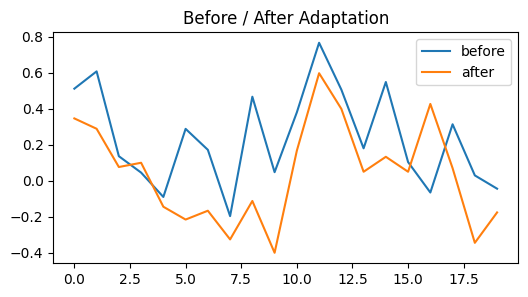

In [12]:
## 12) Utilities: checkpointing and plotting

def save_checkpoint(path: str, model: nn.Module, optimizer: torch.optim.Optimizer = None):
    payload = {'model_state': model.state_dict()}
    if optimizer is not None:
        payload['optim_state'] = optimizer.state_dict()
    torch.save(payload, path)


def load_checkpoint(path: str, model: nn.Module, optimizer: torch.optim.Optimizer = None):
    payload = torch.load(path, map_location=DEVICE)
    model.load_state_dict(payload['model_state'])
    if optimizer is not None and 'optim_state' in payload:
        optimizer.load_state_dict(payload['optim_state'])

def plot_comparison(before, after, title="Before / After Adaptation"):
    plt.figure(figsize=(6,3))
    plt.plot(before.mean(axis=1), label='before')
    plt.plot(after.mean(axis=1), label='after')
    plt.legend()
    plt.title(title)
    plt.show()

plot_comparison(b, a)


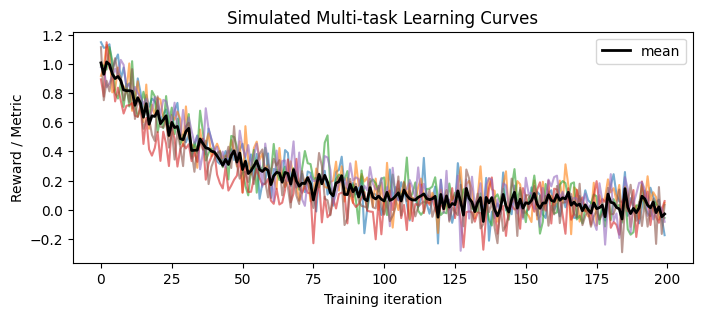

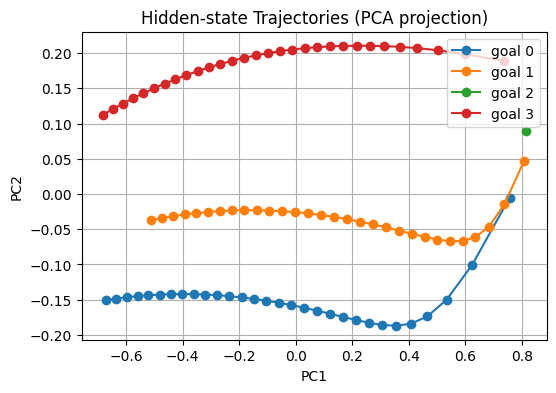

Computing per-goal heatmap (this may take a few seconds)...


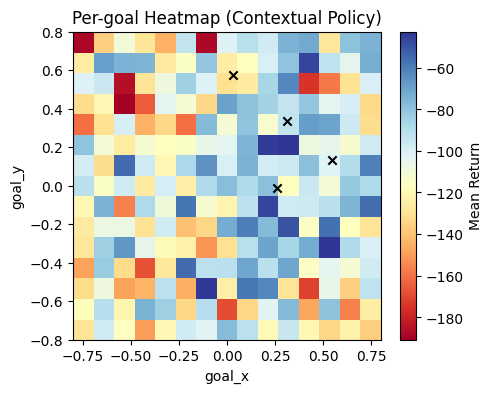

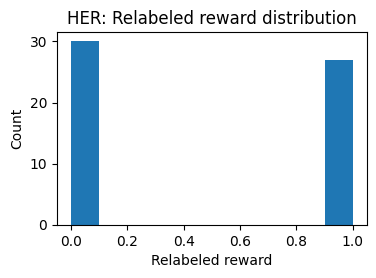

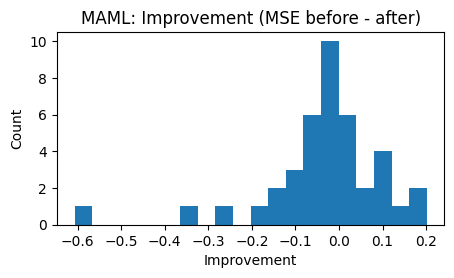

Visualization cells executed.


In [17]:
## Visualization Examples: learning curves, hidden-state trajectories, per-task heatmaps, HER visuals, and MAML improvements

import numpy as np

# Moving average helper
def moving_average(x, window=5):
    if len(x) < window:
        return x
    cumsum = np.cumsum(np.insert(x, 0, 0))
    return (cumsum[window:] - cumsum[:-window]) / float(window)

# 1) Simulated multi-task learning curves (example)
def simulate_learning_curves(num_tasks=5, steps=200):
    curves = []
    for t in range(num_tasks):
        decay = 40 + 10 * np.random.randn()
        noise = 0.05 * np.random.randn(steps)
        curve = np.clip(1.0 * np.exp(-np.arange(steps) / np.abs(decay)) + 0.1 * np.random.randn(steps), -1, 2)
        curves.append(curve)
    return np.array(curves)

curves = simulate_learning_curves(num_tasks=6, steps=200)
plt.figure(figsize=(8,3))
for c in curves:
    plt.plot(c, alpha=0.6)
plt.plot(curves.mean(axis=0), color='k', lw=2, label='mean')
plt.title('Simulated Multi-task Learning Curves')
plt.xlabel('Training iteration')
plt.ylabel('Reward / Metric')
plt.legend()
plt.show()

# 2) Hidden-state trajectories (PCA projection)
def collect_hidden_trajectories(agent, goals, max_steps=30):
    trajs = []
    for i, g in enumerate(goals):
        env = SimpleGoalEnv(goal=g)
        h = None
        states = []
        hs = []
        s = env.reset()
        prev_a = np.zeros(2, dtype=np.float32)
        prev_r = 0.0
        for t in range(max_steps):
            s_t = torch.tensor(s.reshape(1,1,-1), dtype=torch.float32, device=DEVICE)
            prev_a_t = torch.tensor(prev_a.reshape(1,1,-1), dtype=torch.float32, device=DEVICE)
            prev_r_t = torch.tensor([[prev_r]], dtype=torch.float32, device=DEVICE)
            logits, values, h = agent(s_t, prev_a_t, prev_r_t, h)
            # record hidden state h (take first layer h[0])
            if isinstance(h, tuple):
                hvec = h[0].detach().cpu().numpy().squeeze(0).squeeze(0).copy()
            else:
                hvec = h.detach().cpu().numpy().squeeze(0).squeeze(0).copy()
            hs.append(hvec)
            mean = logits.detach().cpu().numpy()[0,0]
            action = np.clip(mean, -env.max_step, env.max_step)
            s_next, r, done, _ = env.step(action)
            prev_a = action
            prev_r = r
            s = s_next
            states.append(s.copy())
            if done:
                break
        trajs.append(np.array(hs))
    return trajs

# Choose a few random goals
goals = [sampler.sample() for _ in range(4)]
trajs = collect_hidden_trajectories(agent, goals, max_steps=30)
# Stack and run PCA (simple SVD)
all_h = np.vstack([t for t in trajs if len(t) > 0])
mean_h = all_h.mean(axis=0)
H = all_h - mean_h
U, S, Vt = np.linalg.svd(H, full_matrices=False)
proj = (H @ Vt.T)[:, :2]
# split back into trajectories
idx = 0
plt.figure(figsize=(6,4))
colors = ['C0','C1','C2','C3']
for i, t in enumerate(trajs):
    l = len(t)
    if l == 0:
        continue
    seg = proj[idx:idx+l]
    plt.plot(seg[:,0], seg[:,1], marker='o', color=colors[i], label=f'goal {i}')
    idx += l
plt.title('Hidden-state Trajectories (PCA projection)')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.legend(); plt.grid(True)
plt.show()

# 3) Per-task heatmap: evaluate policy over a grid of goals
def compute_goal_heatmap(policy, sampler, grid_size=21, episodes=3):
    xs = np.linspace(-sampler.scale, sampler.scale, grid_size)
    ys = np.linspace(-sampler.scale, sampler.scale, grid_size)
    grid = np.zeros((grid_size, grid_size))
    for i, x in enumerate(xs):
        for j, y in enumerate(ys):
            g = np.array([x,y], dtype=np.float32)
            mean_r, succ = evaluate_policy_continuous(policy, SimpleGoalEnv(goal=g), g, episodes=episodes, max_steps=80)
            grid[j,i] = mean_r
    return xs, ys, grid

print('Computing per-goal heatmap (this may take a few seconds)...')
xs, ys, grid = compute_goal_heatmap(policy, sampler, grid_size=15, episodes=3)
plt.figure(figsize=(5,4))
plt.imshow(grid, origin='lower', extent=(xs.min(), xs.max(), ys.min(), ys.max()), cmap='RdYlBu')
plt.colorbar(label='Mean Return')
plt.title('Per-goal Heatmap (Contextual Policy)')
plt.xlabel('goal_x'); plt.ylabel('goal_y')
plt.scatter([g[0] for g in goals], [g[1] for g in goals], c='k', marker='x')
plt.show()

# 4) HER relabel visualization: distribution of relabeled rewards
if len(relabeled) > 0:
    rel_rewards = [r['reward'] for r in relabeled]
    plt.figure(figsize=(4,2.5))
    plt.hist(rel_rewards, bins=10)
    plt.title('HER: Relabeled reward distribution')
    plt.xlabel('Relabeled reward'); plt.ylabel('Count')
    plt.show()

# 5) MAML improvement histogram (before vs after MSE on synthetic queries)
improvements = []
for _ in range(40):
    k_support = 5
    k_query = 20
    support_x = torch.randn(k_support, meta_model.linear.in_features, device=DEVICE)
    support_y = torch.randn(k_support, meta_model.linear.out_features, device=DEVICE)
    query_x = torch.randn(k_query, meta_model.linear.in_features, device=DEVICE)
    query_y = torch.randn(k_query, meta_model.linear.out_features, device=DEVICE)
    before = F.mse_loss(meta_model(query_x), query_y).item()
    phi = inner_loop_adaptation(meta_model, support_x, support_y, alpha=0.1)
    w = phi['linear.weight']; b = phi['linear.bias']
    after = F.mse_loss(query_x.matmul(w.t()) + b, query_y).item()
    improvements.append(before - after)

plt.figure(figsize=(5,2.5))
plt.hist(improvements, bins=20)
plt.title('MAML: Improvement (MSE before - after)')
plt.xlabel('Improvement'); plt.ylabel('Count')
plt.show()

print('Visualization cells executed.')

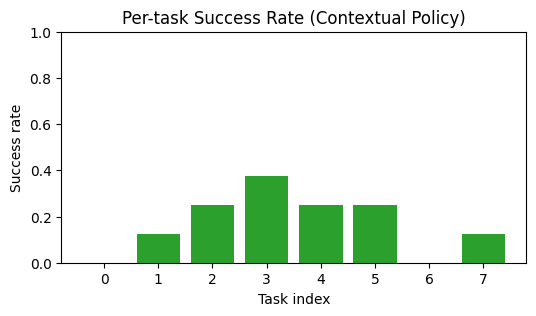

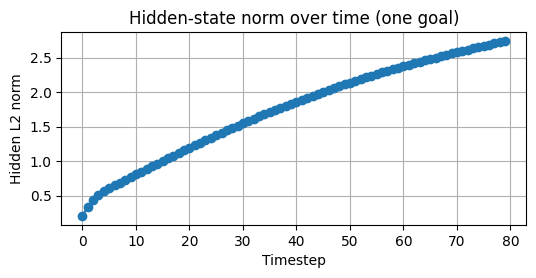

Saved figure to: figs/hidden_norm_example.png
Added additional visualizations.


<Figure size 640x480 with 0 Axes>

In [18]:
## Additional visualizations: per-task success rates, hidden-state norm, and save-fig utility

# 1) Per-task success rates (bar chart)
goals = [sampler.sample() for _ in range(8)]
succs = []
for g in goals:
    _, sr = evaluate_policy_continuous(policy, SimpleGoalEnv(goal=g), g, episodes=8, max_steps=80)
    succs.append(sr)

plt.figure(figsize=(6,3))
plt.bar(range(len(succs)), succs, color='C2')
plt.ylim(0,1)
plt.xlabel('Task index')
plt.ylabel('Success rate')
plt.title('Per-task Success Rate (Contextual Policy)')
plt.show()

# 2) Hidden-state L2 norm over time for one goal (shows how memory grows/changes)
selected_goal = goals[0]
trajs_single = collect_hidden_trajectories(agent, [selected_goal], max_steps=80)
if len(trajs_single) > 0 and len(trajs_single[0])>0:
    norms = np.linalg.norm(trajs_single[0], axis=1)
    plt.figure(figsize=(6,2.5))
    plt.plot(norms, marker='o')
    plt.xlabel('Timestep')
    plt.ylabel('Hidden L2 norm')
    plt.title('Hidden-state norm over time (one goal)')
    plt.grid(True)
    plt.show()
else:
    print('No hidden trajectory collected for plotting.')

# 3) Save-figure helper
import os

def save_fig(name: str):
    os.makedirs('figs', exist_ok=True)
    path = os.path.join('figs', f"{name}.png")
    plt.savefig(path, bbox_inches='tight')
    print(f"Saved figure to: {path}")

# Demonstrate saving the last figure (if any)
if 'norms' in locals() and len(locals().get('norms', []))>0:
    save_fig('hidden_norm_example')

print('Added additional visualizations.')

In [13]:
## 13) Unit tests & sanity checks (shapes, gradient check)

# 1) Check shapes for ContextualPolicy
s = torch.randn(3,2, device=DEVICE)
g = torch.randn(3,2, device=DEVICE)
mean, std = policy(s,g)
assert mean.shape == (3,2)
assert std.shape == (2,)
print("Contextual policy shapes OK")

# 2) Gradient flow check for MAML inner-loop (create_graph True)
meta_model_test = MAMLModel(3,1).to(DEVICE)
x = torch.randn(4,3,device=DEVICE)
y = torch.randn(4,1,device=DEVICE)
phi_test = inner_loop_adaptation(meta_model_test, x, y, alpha=0.2)
# compute a scalar that depends on phi to make sure we can backprop through
w = phi_test['linear.weight']
meta_scalar = w.norm()
# Try to compute gradient to meta params
meta_scalar.backward(retain_graph=True)
print("Gradient-through-adaptation check OK (no exception)")


Contextual policy shapes OK
Gradient-through-adaptation check OK (no exception)



## Lecture 28 — Summary & Key Concepts

**Multi-Task RL (joint MDP view)**
- Treat tasks as samples from a distribution p(M). At the start of each episode sample M_i ~ p(M).
- A single policy π(a|s) operating across tasks can be seen as a policy on an augmented MDP where the state includes task context ω or the goal g.
- Sampling tasks at episode start induces variation in initial state distributions and dynamics.

**Contextual Policies**
- Standard: π(a|s)
- Contextual: π(a|s, ω) where ω encodes the task (e.g., stack location, target direction).
- Formalized by augmenting state: ŝ = (s, ω) and Ŝ = S × Ω.
- Advantage: explicit conditioning (no need to infer tasks from history). Useful when a task descriptor or goal is available.

**Goal-Conditioned Policies**
- π(a|s, g) where g is a desired goal state.
- Reward choices:
  - Exact match: r(s,a,g) = 1[s == g]
  - ε-tolerance region: r(s,a,g) = 1[‖s − g‖ ≤ ε]
- Benefits: easier zero-shot generalization to new goals and reduced per-task reward engineering.
- Drawbacks: training may be hard for sparse rewards; often combined with techniques like Hindsight Experience Replay (HER).

**Meta-RL vs Meta-Learning**
- Meta-learning objective (high-level view):
  θ* = arg max_θ Σ_i E_{π_{ϕ_i}}[R(τ)], where ϕ_i = f_θ(M_i)
- f_θ is the adaptation mechanism (can be an RNN, an optimizer-based update rule, or even another RL procedure).
- During meta-testing sample new M_test ~ p(M) and obtain ϕ_test = f_θ(M_test) via few-shot adaptation.

**Memory-based Meta-RL (RL^2)**
- Use an RNN (LSTM) to process histories τ_t = (s1,a1,r1,...,st) and let the hidden state h_t implicitly encode task identity.
- The policy becomes π_θ(a|s, h_t) and h_t should persist across episodes during meta-training to enable fast adaptation.
- Key design choices: what inputs to the RNN (we often feed (s_t, a_{t-1}, r_{t-1})) and how to manage truncation and BPTT.

**Optimization-based Meta-RL (MAML-style)**
- Inner loop: perform one or more gradient steps per task (ϕ_i = θ − α ∇_θ L_support(θ)).
- Outer loop: aggregate losses on query sets after adaptation and update θ through gradients that flow through the inner updates (use create_graph=True).

> Practical note: Meta-RL automates adaptation; contextual policies require a task descriptor but can be simpler to train when descriptors are available.


In [14]:
# HER utilities & goal-based reward functions

import copy

def exact_goal_reward(state: np.ndarray, goal: np.ndarray) -> float:
    """1 if exact match (useful for discrete toy tasks)."""
    return float(np.allclose(state, goal))

def epsilon_goal_reward(state: np.ndarray, goal: np.ndarray, eps: float = 0.1) -> float:
    """1 if within epsilon ball of the goal; otherwise 0."""
    return float(np.linalg.norm(state - goal) <= eps)


def her_relabel(trajectory: Dict[str, Any], k_future: int = 4, eps: float = 0.1) -> List[Dict[str, Any]]:
    """Simple Hindsight Experience Replay (future strategy) relabeling.

    For each time index t, sample up to k_future future time steps and use the corresponding
    future next_state as a pseudo-goal; recompute reward accordingly and yield relabeled
    transitions (state, action, reward', next_state, goal').
    """
    T = len(trajectory['states'])
    relabeled = []
    for t in range(T):
        if t >= T:
            break
        future_idxs = list(range(t, T))
        if len(future_idxs) == 0:
            continue
        # Draw up to k_future future indices randomly
        chosen = np.random.choice(future_idxs, size=min(k_future, len(future_idxs)), replace=False)
        for idx in chosen:
            new_goal = trajectory['next_states'][idx]
            r_new = epsilon_goal_reward(trajectory['next_states'][t], new_goal, eps=eps)
            relabeled.append({
                'state': trajectory['states'][t],
                'action': trajectory['actions'][t],
                'reward': r_new,
                'next_state': trajectory['next_states'][t],
                'done': trajectory['dones'][t],
                'goal': new_goal
            })
    return relabeled

# Demo: collect a random rollout from SimpleGoalEnv and relabel
traj = {'states': [], 'actions': [], 'rewards': [], 'next_states': [], 'dones': []}
env = SimpleGoalEnv(goal=sampler.sample())
obs = env.reset()
for t in range(20):
    a = np.random.uniform(-env.max_step, env.max_step, size=(2,))
    s_next, r, done, _ = env.step(a)
    traj['states'].append(obs)
    traj['actions'].append(a)
    traj['rewards'].append(r)
    traj['next_states'].append(s_next)
    traj['dones'].append(done)
    obs = s_next
    if done:
        break

relabeled = her_relabel(traj, k_future=3, eps=0.1)
print(f"Original steps: {len(traj['states'])}, Relabeled samples: {len(relabeled)}")
print("Example relabeled entry:", relabeled[0] if len(relabeled) else 'None')


Original steps: 20, Relabeled samples: 57
Example relabeled entry: {'state': array([0.07126561, 0.17981996], dtype=float32), 'action': array([ 0.04602441, -0.037611  ]), 'reward': 1.0, 'next_state': array([0.11729001, 0.14220896]), 'done': False, 'goal': array([0.03417283, 0.17305218])}


In [15]:
# RL^2 hidden-state persistence demo (showing non-reset between episodes)

print("--- RL^2 Hidden-State Persistence Demo ---")
agent = RecurrentMetaRLAgent(state_dim=2, action_dim=2).to(DEVICE)

# small helper to run a single episode step-by-step, preserving hidden state if provided

def run_episode(agent, env, hidden=None, max_steps=20):
    s = env.reset()
    prev_a = np.zeros(2, dtype=np.float32)
    prev_r = 0.0
    total_r = 0.0
    for t in range(max_steps):
        s_t = torch.tensor(s.reshape(1,1,-1), dtype=torch.float32, device=DEVICE)
        prev_a_t = torch.tensor(prev_a.reshape(1,1,-1), dtype=torch.float32, device=DEVICE)
        prev_r_t = torch.tensor([[prev_r]], dtype=torch.float32, device=DEVICE)

        logits, values, hidden = agent(s_t, prev_a_t, prev_r_t, hidden)
        # Use the first time-step output (since we provide one-step sequences)
        mean = logits.detach().cpu().numpy()[0,0]
        action = np.clip(mean, -env.max_step, env.max_step)
        s_next, r, done, _ = env.step(action)
        total_r += r
        prev_a = action
        prev_r = r
        s = s_next
        if done:
            break
    return total_r, hidden

# Prepare environment with a fixed goal
goal = sampler.sample()
env = SimpleGoalEnv(goal=goal)

# Episode 1 (fresh hidden)
total1, hidden1 = run_episode(agent, env, hidden=None, max_steps=20)
# Episode 2 (hidden reset)
total2, hidden2 = run_episode(agent, env, hidden=None, max_steps=20)
# Episode 3 (carry-over hidden from episode 1)
total3, hidden3 = run_episode(agent, env, hidden=hidden1, max_steps=20)

print(f"Total rewards: Ep1={total1:.3f}, Ep2={total2:.3f}, Ep3(with carry)={total3:.3f}")
# Check hidden states are not identical when carried over
if isinstance(hidden1, tuple):
    h1 = hidden1[0].detach().cpu().numpy()
    h2 = hidden2[0].detach().cpu().numpy()
    h3 = hidden3[0].detach().cpu().numpy()
    diff12 = np.linalg.norm(h1 - h2)
    diff13 = np.linalg.norm(h1 - h3)
    print(f"Hidden L2 differences: |h1-h2|={diff12:.6f}, |h1-h3|={diff13:.6f}")

assert diff12 >= 0.0  # sanity

print("If hidden state is carried (Ep3) it can differ from a fresh hidden initialization (Ep2).")


--- RL^2 Hidden-State Persistence Demo ---
Total rewards: Ep1=-27.240, Ep2=-22.597, Ep3(with carry)=-35.067
Hidden L2 differences: |h1-h2|=0.248103, |h1-h3|=0.149947
If hidden state is carried (Ep3) it can differ from a fresh hidden initialization (Ep2).
